Hello, this is the main function!
The real means of underlying variables are 
[8.97822266 3.70367375 0.91716352 6.77369225 1.50819643 5.28111667
 6.91859192 1.17126036]
The highest mean is  8.978222661205212  at arm 0
Proportion of times each arm was pulled in the policy when epsilon = 0.05
[0.927 0.01  0.002 0.023 0.01  0.005 0.012 0.01 ]
Proportion of times each arm was pulled in the policy when epsilon = 0.1
[0.903 0.017 0.013 0.012 0.018 0.01  0.011 0.015]
Proportion of times each arm was pulled in the policy when epsilon = 0.2
[0.826 0.019 0.029 0.03  0.027 0.021 0.025 0.022]
Proportion of times each arm was pulled in the policy when epsilon = 0.4
[0.627 0.051 0.056 0.043 0.065 0.042 0.062 0.053]


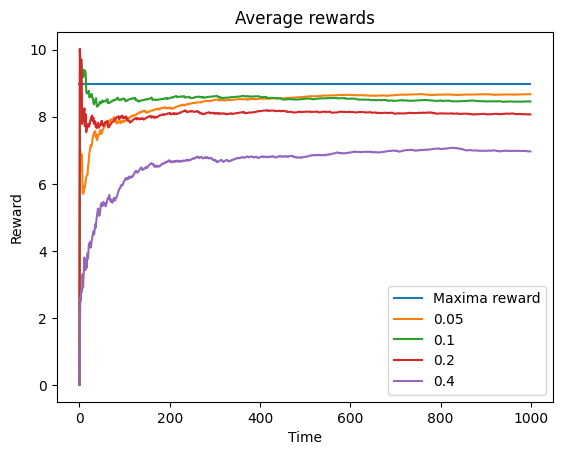

In [24]:
import numpy as np
import matplotlib.pyplot as plt

class Bandit:

    # T - number of time slots 
    # N - number of bandits 

    def generate_means(self,N):
        
        return np.random.uniform(0, 10, N)


    def generate_arms(self,N, T):
        arms = []  

        for i in range(N):
            # Generate an array of size T with normal random variables
            arm = np.random.normal(self.means[i], 1, T)
            arms.append(arm)

        return arms         
    

    def __init__(self, T, N): 
        self.T = T 
        self.N = N 
        self.curr =0
        # generate means of normal random variables 
        self.means = self.generate_means(N)
        # generate T normal random variable with the above means and unit variance for each arm 
        self.arms = self.generate_arms(N,T)
        # number of rewards of arm i that have been returned so far 
        self.curr_position = np.zeros(N, dtype=int)
        self.rewards = np.zeros(self.T)

     
    def reset(self):
        self.curr_position = np.zeros(self.N, dtype=int)
        self.rewards = np.zeros(self.T)

        self.curr = 0

    def proportions(self): 

        return self.curr_position/self.T 
    

    def next(self, i):
        """

            This function takes i as a parameter and returns the next reward of item i 

        """
        self.curr_position[i]+=1
        reward = self.arms[i][self.curr_position[i]]
        self.curr+=1 
        self.rewards [self.curr] =  self.rewards [self.curr-1]+reward
        return reward 
    
    def curr_arm(self, i):

        return self.curr_position[i]


class EpsilonGreedyPolicy:


    def __init__(self, N, epsilon, bandit):
        """
            N - number of arms in the bandit problem
            epsilon - parameter of epsilon greedy policy
            average - array of averages of arm i. 
            bandit - an instance of class Bandit containing rewards 
        """    
        self.N = N 
        self.epsilon = epsilon  
        self.averages = np.zeros(N)
        self.bandit = bandit 
      

    def run(self):
        """
            applies the policy 
        """
        
        for t in range(1,self.bandit.T):

            u = np.random.uniform(0, 1)
            if (u< self.epsilon):
                arm = np.random.randint(0, self.N)
            else:    
                max_value = np.max(self.averages)
                arm1 = np.where(self.averages == max_value)[0]
                arm = arm1[0]
            reward = self.bandit.next(arm)
            num_curr_arm =  self.bandit.curr_arm(arm)
            self.averages[arm] = ((num_curr_arm-1)*self.averages[arm]+reward)/num_curr_arm 


def main():
    print("Hello, this is the main function!")

    T = 1000
    N = 8 
    
    bandit = Bandit(T,N)
    print("The real means of underlying variables are ")
    print(bandit.means)
    max_mean = np.max(bandit.means)
    print("The highest mean is ", max_mean , " at arm",np.where(bandit.means == max_mean)[0][0])
    plt.plot(max_mean*np.ones(T), label="Maximal reward")
    
    for epsilon in [0.05, 0.1, 0.2, 0.4]:
        epsilon_greedy_policy = EpsilonGreedyPolicy(N,epsilon,bandit)
        epsilon_greedy_policy.run()
        print("Proportion of times each arm was pulled in the policy when epsilon =", epsilon)
        print(bandit.proportions())
        average_reward = np.zeros(T)
        for l in range(1,T):
            average_reward[l]=bandit.rewards[l]/l 
        plt.plot(average_reward, label=str(epsilon))
        bandit.reset()

    # Plot cumulative rewards
    plt.xlabel('Time')
    plt.ylabel('Reward')
    plt.title('Average rewards')
    plt.legend()
    #plt.text(0,2200,'Maximal possible reward = '+ str(int(T*max_mean)))
    
    plt.show()

# Check if the script is being run directly by Python (not imported as a module)
if __name__ == "__main__":
    # Call the main function
    main()